# Notebook 05 — Customer Segmentation

**Tier:** 2 / 3 — Diagnostic & Predictive  
**Purpose:** RFM scoring, K-Means clustering, repeat-customer analysis.  
**Input:** `outputs/feature_store.parquet`  
**Output:** `outputs/reports/rfm_segments.csv`, `outputs/reports/cluster_profiles.csv`, charts  

> **Important caveat:** 148,788 unique Customer IDs across 150,000 bookings.
> Most customers appear only once — RFM and clusters reflect this reality.
> Per-customer cumulative revenue is reported as **OCV (Observed Customer Value)** — NOT LTV.
> Net revenue, driver payout, and margin are unavailable.

In [2]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 5.1 Repeat Customer Analysis

In [3]:
rides_per_cust = df.groupby('Customer ID').size()
one_ride   = (rides_per_cust == 1).sum()
two_rides  = (rides_per_cust == 2).sum()
three_plus = (rides_per_cust >= 3).sum()
total_custs = rides_per_cust.nunique() if hasattr(rides_per_cust, 'nunique') else len(rides_per_cust)

print(f'Unique customers       : {len(rides_per_cust):,}')
print(f'  1 ride               : {one_ride:,}  ({one_ride/len(rides_per_cust)*100:.1f}%)')
print(f'  2 rides              : {two_rides:,}  ({two_rides/len(rides_per_cust)*100:.1f}%)')
print(f'  3+ rides             : {three_plus:,}  ({three_plus/len(rides_per_cust)*100:.1f}%)')

repeat_ids = rides_per_cust[rides_per_cust > 1].index
repeat_mask = df['Customer ID'].isin(repeat_ids)
print(f'\nCompletion rate — one-time : {df[~repeat_mask]["is_completed"].mean()*100:.1f}%')
print(f'Completion rate — repeat   : {df[repeat_mask]["is_completed"].mean()*100:.1f}%')

Unique customers       : 148,788
  1 ride               : 147,582  (99.2%)
  2 rides              : 1,200  (0.8%)
  3+ rides             : 6  (0.0%)

Completion rate — one-time : 62.0%
Completion rate — repeat   : 61.4%


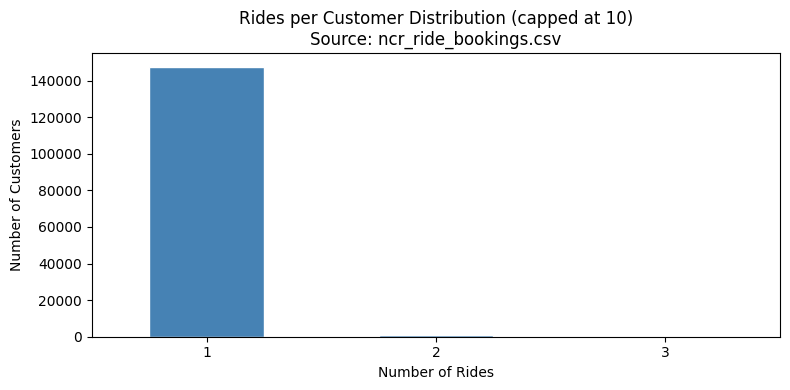

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
rides_per_cust.clip(upper=10).value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Rides per Customer Distribution (capped at 10)\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Number of Rides'); ax.set_ylabel('Number of Customers')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
fig.savefig('outputs/plots/05_rides_per_customer.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Observed Customer Value (OCV) — NOT LTV
cust_ocv_repeat   = completed[completed['Customer ID'].isin(repeat_ids)].groupby('Customer ID')['Booking Value'].sum()
cust_ocv_onetime  = completed[~completed['Customer ID'].isin(repeat_ids)].groupby('Customer ID')['Booking Value'].sum()
print(f'Avg OCV — one-time customers : ₹{cust_ocv_onetime.mean():.0f}')
print(f'Avg OCV — repeat customers   : ₹{cust_ocv_repeat.mean():.0f}')
print()
print('Note: OCV = sum of Booking Value on completed rides within observation window.')
print('      It is NOT LTV; it makes no forward projection and no claim about profitability.')

Avg OCV — one-time customers : ₹508
Avg OCV — repeat customers   : ₹721

Note: OCV = sum of Booking Value on completed rides within observation window.
      It is NOT LTV; it makes no forward projection and no claim about profitability.


## 5.2 RFM Scoring

In [6]:
from src.segmentation import build_rfm

rfm = build_rfm(df)
print(f'RFM table shape: {rfm.shape}')
print(rfm.head())

RFM table shape: (148788, 9)
  Customer ID  recency_days  frequency  monetary_ocv  R  F  M rfm_score  \
0  CID1000119           287          1           0.0  1  1  1       111   
1  CID1000157           178          1           0.0  3  1  1       311   
2  CID1000234            95          1         458.0  3  1  3       313   
3  CID1000323           283          1        1498.0  1  1  4       114   
4  CID1000434             2          1           0.0  4  1  1       411   

          rfm_segment  
0                Lost  
1  Potential Loyalist  
2  Potential Loyalist  
3                Lost  
4  Potential Loyalist  


RFM Segment Sizes:
rfm_segment
Potential Loyalist    37182
Lost                  36974
Loyal                 35486
At Risk               27711
Hibernating            9306
Champion               2129

Saved: outputs/reports/rfm_segments.csv


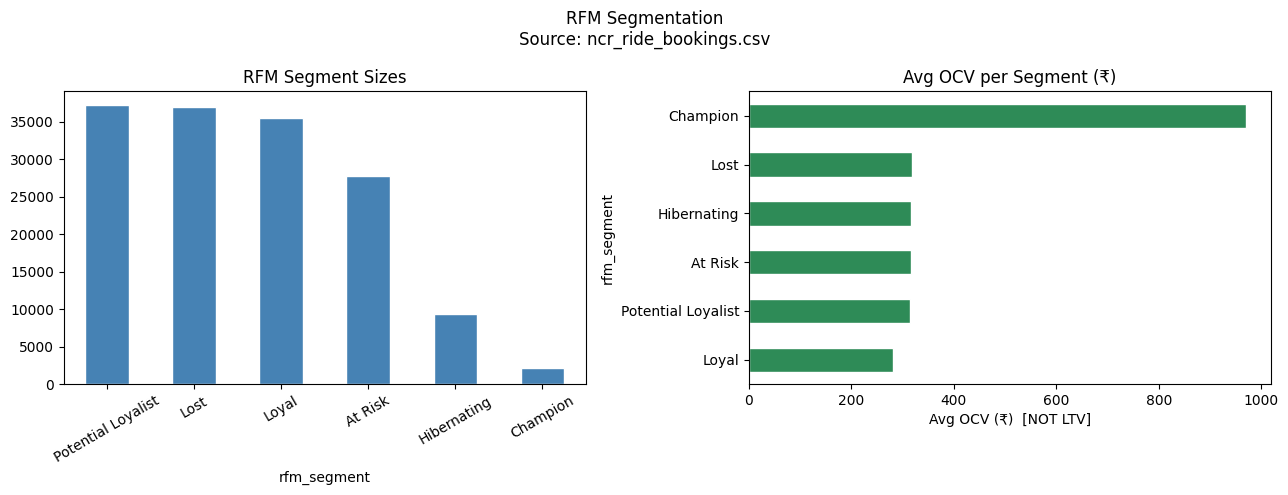

In [7]:
seg_counts = rfm['rfm_segment'].value_counts()
print('RFM Segment Sizes:'); print(seg_counts.to_string())
rfm.to_csv('outputs/reports/rfm_segments.csv', index=False)
print('\nSaved: outputs/reports/rfm_segments.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
seg_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('RFM Segment Sizes'); axes[0].tick_params(axis='x', rotation=30)

rfm.groupby('rfm_segment')['monetary_ocv'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Avg OCV per Segment (₹)')
axes[1].set_xlabel('Avg OCV (₹)  [NOT LTV]')
fig.suptitle('RFM Segmentation\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/05_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.3 K-Means Clustering

In [8]:
from src.segmentation import build_cluster_features, run_kmeans, pca_2d
import numpy as np
from sklearn.preprocessing import StandardScaler

feat_df = build_cluster_features(df)
print(f'Cluster feature matrix: {feat_df.shape}')
print(feat_df.head(3))

NameError: name 'avg_driver_rating_given' is not defined

In [ ]:
best_model, labels, scaler, elbow_df = run_kmeans(feat_df, k_range=range(2, 8))
print(elbow_df.to_string(index=False))
best_k = int(elbow_df.loc[elbow_df['silhouette'].idxmax(), 'k'])
print(f'\nSelected k = {best_k}  (highest silhouette score)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
elbow_df.plot(x='k', y='inertia', marker='o', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Elbow Plot (Inertia)'); axes[0].set_xlabel('k')
elbow_df.plot(x='k', y='silhouette', marker='o', ax=axes[1], legend=False, color='seagreen')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')
plt.tight_layout()
fig.savefig('outputs/plots/05_kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
feat_df = feat_df.copy()
feat_df['cluster'] = labels

numeric_cols = feat_df.select_dtypes(include='number').columns.drop('cluster').tolist()
X_scaled = scaler.transform(feat_df[numeric_cols].fillna(0))
coords = pca_2d(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for cl in sorted(feat_df['cluster'].unique()):
    mask = feat_df['cluster'] == cl
    ax.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {cl}', alpha=0.5, s=8)
ax.set_title(f'Customer Clusters (PCA 2D, k={best_k})\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend()
plt.tight_layout()
fig.savefig('outputs/plots/05_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.4 Cluster Profiles

In [ ]:
profile = feat_df.groupby('cluster')[numeric_cols].mean().round(2)
print('Cluster profiles (mean features):')
print(profile.T.to_string())
profile.to_csv('outputs/reports/cluster_profiles.csv')
print('\nSaved: outputs/reports/cluster_profiles.csv')

## Limitations
- OCV is reported as a proxy for customer value. It is **not** LTV — no forward projection, no cost deduction.
- CAC, ROAS, driver payout, commission, operating cost, and contribution margin are all **unavailable** (no cost fields).
- Most customers appear only once in 2024; clustering is driven primarily by single-trip behaviour.